In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nfedorov/top-2000-board-games-ratings/bgg_ratings_top_2000.feather
/kaggle/input/datasets/nfedorov/top-2000-board-games-ratings/bgg_boardgames_top_2000.feather


The dataset used for this  is the "Top 2000 Board Games Ratings" by Nikita Fedorov, found [here](https://www.kaggle.com/datasets/nfedorov/top-2000-board-games-ratings). No changes were made to the data set prior to loading it. 

In [31]:
#importing ratings dataset
ratings=pd.read_feather("/kaggle/input/datasets/nfedorov/top-2000-board-games-ratings/bgg_ratings_top_2000.feather")



In [32]:
#importing games  dataset
games=pd.read_feather("/kaggle/input/datasets/nfedorov/top-2000-board-games-ratings/bgg_boardgames_top_2000.feather")



In [33]:
#printing column names
print(games.columns)

Index(['boardgame_id', 'title', 'year_published', 'minplayers', 'maxplayers',
       'minplaytime', 'maxplaytime', 'age', 'users_rated', 'average_rating',
       'bayes_average_rating', 'median', 'stddev', 'owned', 'trading',
       'wishing', 'num_of_comments', 'num_of_weights', 'average_weight',
       'ranks', 'main_publisher', 'description', 'publishers', 'honors',
       'expansions', 'accessories', 'artists', 'mechanics', 'category',
       'designers', 'graphic_designers', 'subdomains', 'implementations',
       'suggested_numplayers', 'podcast_episodes', 'comments',
       'marketplace_history', 'thumbnail_link', 'image_link'],
      dtype='object')


In [34]:
#dropping columns I do not intend to use in analysis

games.drop(["thumbnail_link","image_link","podcast_episodes","description","artists","marketplace_history"],axis=1)

,boardgame_id,title,year_published,minplayers,maxplayers,minplaytime,maxplaytime,age,users_rated,average_rating,...,expansions,accessories,mechanics,category,designers,graphic_designers,subdomains,implementations,suggested_numplayers,comments
0,77423,The Lord of the Rings: The Card Game,2011,1,2,30,60,13,23231,7.66006,...,The Lord of the Rings: The Card Game – A Journ...,Arkham Edge Laserox Organizer|The Lord of the ...,Cooperative Game|Deck Construction|Events|Hand...,Adventure|Card Game|Collectible Components|Fan...,Nate French,None,Customizable Games,The Lord of the Rings: The Card Game – Revised...,1||Best~221|Recommended~368|Not Recommended~45...,"0 1 1 2 3 5 8|Recommended by Joel D., Chris S...."
1,88,Torres,1999,2,4,60,60,12,9398,7.09677,...,None,None,Action Points|Area Majority / Influence|Enclos...,Abstract Strategy|Medieval,Michael Kiesling|Wolfgang Kramer,Sabine Kondirolli,Abstract Games|Strategy Games,Torres Family|Burgenland,1||Best~0|Recommended~0|Not Recommended~71|||2...,-Johnny-|One play. Didn't do it for me at all....
2,203420,Exit: The Game – The Abandoned Cabin,2016,1,6,60,120,12,10691,7.45508,...,None,KOSMOS Helper App,Cooperative Game,Deduction|Puzzle|Real-time,Inka Brand|Markus Brand,None,Family Games|Thematic Games,None,1||Best~6|Recommended~79|Not Recommended~38|||...,-Johnny-|Not actually a game. More of an activ...
3,310448,Zombie Teenz Evolution,2020,2,4,15,25,8,1321,7.78381,...,None,None,Action Points|Cooperative Game|Dice Rolling|Ev...,Children's Game|Zombies,Annick Lobet,None,Family Games,Zombie Kidz Evolution,1||Best~0|Recommended~4|Not Recommended~8|||2|...,"21kellie08|Jackson’s||Adam78|I went into this,..."
4,25417,BattleLore,2006,2,2,60,60,10,9264,7.35379,...,BattleLore: Bearded Brave|BattleLore: Call to ...,BattleLore: Extra Dice Set,Area Majority / Influence|Campaign / Battle Ca...,Fantasy|Medieval|Miniatures|Wargame,Richard Borg,None,Thematic Games|Wargames,BattleLore: Second Edition|Battles of Westeros,1||Best~2|Recommended~10|Not Recommended~90|||...,1000rpm|Rating based on 3 plays of the most ba...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,332800,Summoner Wars (Second Edition),2021,2,2,40,60,9,2430,8.21032,...,Summoner Wars (Second Edition): Ashia the Sile...,Summoner Wars (Second Edition): Play Mat|Summo...,Action Points|Card Play Conflict Resolution|De...,Card Game|Fantasy|Fighting,Colby Dauch,None,Customizable Games|Strategy Games,Summoner Wars|Summoner Wars: Master Set,1||Best~0|Recommended~0|Not Recommended~24|||2...,2Face|I typically prefer miniature games over ...
1995,274841,Cóatl,2020,1,4,30,60,10,2177,7.00157,...,Cóatl: Promo Cards,Cóatl: Metal Start Player Token,Contracts|Hand Management|Once-Per-Game Abilit...,Abstract Strategy|Puzzle,Pascale Brassard|Etienne Dubois-Roy,None,Family Games,None,1||Best~0|Recommended~12|Not Recommended~5|||2...,Aalon102|Underrated game that needs more hype ...
1996,163413,Murano,2014,2,4,60,75,10,2165,7.18261,...,Murano: Promo Cards|Murano: The Christmas Tree,None,Point to Point Movement|Tile Placement,City Building|Economic,Inka Brand|Markus Brand,None,Strategy Games,None,1||Best~0|Recommended~0|Not Recommended~25|||2...,1979 AMC Treo 755p|1007||210pasadena|really li...
1997,223931,Sherlock Holmes Consulting Detective: Carlton ...,2017,1,8,90,90,12,1137,7.86478,...,None,None,Cooperative Game|Storytelling,Deduction|Murder/Mystery|Novel-based|Post-Napo...,Thomas Cauët|Raymond Edwards|Suzanne Goldberg|...,None,Thematic Games,Sherlock Holmes Consulting Detective: The Mans...,1||Best~1|Recommended~7|Not Recommended~2|||2|...,1Peter567|Mystery; Cooperative.\nUnopened; Org...


In [35]:
#Function for dealing with none values in columns I am creating count columns for 

def count_list(count_list):
    if isinstance(count_list, list):
        return len(count_list)
    else:
        return 0


In [36]:
# creating count columns from existing features 
#for honor column

print(games["honors"])

#splitting the honors separately on the "|"
games["honor_split"]=games["honors"].str.split(pat="|")
games["honor_count"]=games["honor_split"].apply(count_list)

#dropping original honor column 

games.drop('honors', axis='columns')



0       2011 Golden Geek Best 2-Player Board Game Nomi...
1       2000 Deutscher Spiele Preis Best Family/Adult ...
2       2017 Hra roku Recommended|2017 Kennerspiel des...
3       2020 Board Game Quest Awards Best Family Game ...
4       2007 Golden Geek Best 2-Player Board Game Nomi...
                              ...                        
1994    2021 Golden Geek Best 2-Player Board Game Nominee
1995    2020 5 Seasons Best International Artwork Nomi...
1996                                                 None
1997                                                 None
1998    1999 Charles S. Roberts Best Pre-World War II ...
Name: honors, Length: 1999, dtype: object


,boardgame_id,title,year_published,minplayers,maxplayers,minplaytime,maxplaytime,age,users_rated,average_rating,...,subdomains,implementations,suggested_numplayers,podcast_episodes,comments,marketplace_history,thumbnail_link,image_link,honor_split,honor_count
0,77423,The Lord of the Rings: The Card Game,2011,1,2,30,60,13,23231,7.66006,...,Customizable Games,The Lord of the Rings: The Card Game – Revised...,1||Best~221|Recommended~368|Not Recommended~45...,005 – Emergent Narrative &amp; Storytelling in...,"0 1 1 2 3 5 8|Recommended by Joel D., Chris S....",unix_saledate|1301347058||saletime|120837||pri...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,[2011 Golden Geek Best 2-Player Board Game Nom...,7
1,88,Torres,1999,2,4,60,60,12,9398,7.09677,...,Abstract Games|Strategy Games,Torres Family|Burgenland,1||Best~0|Recommended~0|Not Recommended~71|||2...,"BGTG 115 - Spiel des Jahres, Then &amp; Now|BG...",-Johnny-|One play. Didn't do it for me at all....,unix_saledate|1047560215||saletime|9025580||pr...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,[2000 Deutscher Spiele Preis Best Family/Adult...,6
2,203420,Exit: The Game – The Abandoned Cabin,2016,1,6,60,120,12,10691,7.45508,...,Family Games|Thematic Games,None,1||Best~6|Recommended~79|Not Recommended~38|||...,"34. Devon Dice Podcast, Near &amp; Far, Dice F...",-Johnny-|Not actually a game. More of an activ...,unix_saledate|1488266932||saletime|992349||pri...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,"[2017 Hra roku Recommended, 2017 Kennerspiel d...",4
3,310448,Zombie Teenz Evolution,2020,2,4,15,25,8,1321,7.78381,...,Family Games,Zombie Kidz Evolution,1||Best~0|Recommended~4|Not Recommended~8|||2|...,"Episode 112 - Bonfire, Hostage Negotiator, Aeo...","21kellie08|Jackson’s||Adam78|I went into this,...",unix_saledate|1608485820||saletime|1710444||pr...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,[2020 Board Game Quest Awards Best Family Game...,9
4,25417,BattleLore,2006,2,2,60,60,10,9264,7.35379,...,Thematic Games|Wargames,BattleLore: Second Edition|Battles of Westeros,1||Best~2|Recommended~10|Not Recommended~90|||...,BGWS 035 – BattleLore|D6G Episode 13: Battlelo...,1000rpm|Rating based on 3 plays of the most ba...,unix_saledate|1165637847||saletime|445093||pri...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,[2007 Golden Geek Best 2-Player Board Game Nom...,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,332800,Summoner Wars (Second Edition),2021,2,2,40,60,9,2430,8.21032,...,Customizable Games|Strategy Games,Summoner Wars|Summoner Wars: Master Set,1||Best~0|Recommended~0|Not Recommended~24|||2...,Episode 108 - Top Board Games - 40-31 (2022)|E...,2Face|I typically prefer miniature games over ...,unix_saledate|1629895365||saletime|792693||pri...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,[2021 Golden Geek Best 2-Player Board Game Nom...,1
1995,274841,Cóatl,2020,1,4,30,60,10,2177,7.00157,...,Family Games,None,1||Best~0|Recommended~12|Not Recommended~5|||2...,"Episode 188: Bonfire|Episode 51: Tang Garden, ...",Aalon102|Underrated game that needs more hype ...,unix_saledate|1602524408||saletime|645346||pri...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,[2020 5 Seasons Best International Artwork Nom...,6
1996,163413,Murano,2014,2,4,60,75,10,2165,7.18261,...,Strategy Games,None,1||Best~0|Recommended~0|Not Recommended~25|||2...,Ep. 16 – UnPub 5 and Roll for the Galaxy | Pod...,1979 AMC Treo 755p|1007||210pasadena|really li...,unix_saledate|1416078030||saletime|1836897||pr...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,https://cf.geekdo-images.com/1UIYr

In [37]:
#count column for expansions

#splitting the accessories separately on the "|"
games["expansion_split"]=games["expansions"].str.split(pat="|")
games["expansion_count"]=games["expansion_split"].apply(count_list)

games.drop('expansions', axis='columns')



,boardgame_id,title,year_published,minplayers,maxplayers,minplaytime,maxplaytime,age,users_rated,average_rating,...,suggested_numplayers,podcast_episodes,comments,marketplace_history,thumbnail_link,image_link,honor_split,honor_count,expansion_split,expansion_count
0,77423,The Lord of the Rings: The Card Game,2011,1,2,30,60,13,23231,7.66006,...,1||Best~221|Recommended~368|Not Recommended~45...,005 – Emergent Narrative &amp; Storytelling in...,"0 1 1 2 3 5 8|Recommended by Joel D., Chris S....",unix_saledate|1301347058||saletime|120837||pri...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,[2011 Golden Geek Best 2-Player Board Game Nom...,7,[The Lord of the Rings: The Card Game – A Jour...,147
1,88,Torres,1999,2,4,60,60,12,9398,7.09677,...,1||Best~0|Recommended~0|Not Recommended~71|||2...,"BGTG 115 - Spiel des Jahres, Then &amp; Now|BG...",-Johnny-|One play. Didn't do it for me at all....,unix_saledate|1047560215||saletime|9025580||pr...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,[2000 Deutscher Spiele Preis Best Family/Adult...,6,None,0
2,203420,Exit: The Game – The Abandoned Cabin,2016,1,6,60,120,12,10691,7.45508,...,1||Best~6|Recommended~79|Not Recommended~38|||...,"34. Devon Dice Podcast, Near &amp; Far, Dice F...",-Johnny-|Not actually a game. More of an activ...,unix_saledate|1488266932||saletime|992349||pri...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,"[2017 Hra roku Recommended, 2017 Kennerspiel d...",4,None,0
3,310448,Zombie Teenz Evolution,2020,2,4,15,25,8,1321,7.78381,...,1||Best~0|Recommended~4|Not Recommended~8|||2|...,"Episode 112 - Bonfire, Hostage Negotiator, Aeo...","21kellie08|Jackson’s||Adam78|I went into this,...",unix_saledate|1608485820||saletime|1710444||pr...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,[2020 Board Game Quest Awards Best Family Game...,9,None,0
4,25417,BattleLore,2006,2,2,60,60,10,9264,7.35379,...,1||Best~2|Recommended~10|Not Recommended~90|||...,BGWS 035 – BattleLore|D6G Episode 13: Battlelo...,1000rpm|Rating based on 3 plays of the most ba...,unix_saledate|1165637847||saletime|445093||pri...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,[2007 Golden Geek Best 2-Player Board Game Nom...,9,"[BattleLore: Bearded Brave, BattleLore: Call t...",16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,332800,Summoner Wars (Second Edition),2021,2,2,40,60,9,2430,8.21032,...,1||Best~0|Recommended~0|Not Recommended~24|||2...,Episode 108 - Top Board Games - 40-31 (2022)|E...,2Face|I typically prefer miniature games over ...,unix_saledate|1629895365||saletime|792693||pri...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,[2021 Golden Geek Best 2-Player Board Game Nom...,1,[Summoner Wars (Second Edition): Ashia the Sil...,14
1995,274841,Cóatl,2020,1,4,30,60,10,2177,7.00157,...,1||Best~0|Recommended~12|Not Recommended~5|||2...,"Episode 188: Bonfire|Episode 51: Tang Garden, ...",Aalon102|Underrated game that needs more hype ...,unix_saledate|1602524408||saletime|645346||pri...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,[2020 5 Seasons Best International Artwork Nom...,6,[Cóatl: Promo Cards],1
1996,163413,Murano,2014,2,4,60,75,10,2165,7.18261,...,1||Best~0|Recommended~0|Not Recommended~25|||2...,Ep. 16 – UnPub 5 and Roll for the Galaxy | Pod...,1979 AMC Treo 755p|1007||210pasadena|really li...,unix_saledate|1416078030||saletime|1836897||pr...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,None,0,"[Murano: Promo Cards, Murano: The Christmas Tree]",2
1997,223931,Sherlock Holmes Consulting Detective: Carlton ...,2017,1,8,90,90,12,1137,7.

In [38]:
#count column for accessories 



#splitting the accessories separately on the "|"
games["accessory_split"]=games["accessories"].str.split(pat="|")
games["accessory_count"]=games["accessory_split"].apply(count_list)


games.drop('expansions', axis='columns')

,boardgame_id,title,year_published,minplayers,maxplayers,minplaytime,maxplaytime,age,users_rated,average_rating,...,comments,marketplace_history,thumbnail_link,image_link,honor_split,honor_count,expansion_split,expansion_count,accessory_split,accessory_count
0,77423,The Lord of the Rings: The Card Game,2011,1,2,30,60,13,23231,7.66006,...,"0 1 1 2 3 5 8|Recommended by Joel D., Chris S....",unix_saledate|1301347058||saletime|120837||pri...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,[2011 Golden Geek Best 2-Player Board Game Nom...,7,[The Lord of the Rings: The Card Game – A Jour...,147,"[Arkham Edge Laserox Organizer, The Lord of th...",5
1,88,Torres,1999,2,4,60,60,12,9398,7.09677,...,-Johnny-|One play. Didn't do it for me at all....,unix_saledate|1047560215||saletime|9025580||pr...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,[2000 Deutscher Spiele Preis Best Family/Adult...,6,None,0,None,0
2,203420,Exit: The Game – The Abandoned Cabin,2016,1,6,60,120,12,10691,7.45508,...,-Johnny-|Not actually a game. More of an activ...,unix_saledate|1488266932||saletime|992349||pri...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,"[2017 Hra roku Recommended, 2017 Kennerspiel d...",4,None,0,[KOSMOS Helper App],1
3,310448,Zombie Teenz Evolution,2020,2,4,15,25,8,1321,7.78381,...,"21kellie08|Jackson’s||Adam78|I went into this,...",unix_saledate|1608485820||saletime|1710444||pr...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,[2020 Board Game Quest Awards Best Family Game...,9,None,0,None,0
4,25417,BattleLore,2006,2,2,60,60,10,9264,7.35379,...,1000rpm|Rating based on 3 plays of the most ba...,unix_saledate|1165637847||saletime|445093||pri...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,[2007 Golden Geek Best 2-Player Board Game Nom...,9,"[BattleLore: Bearded Brave, BattleLore: Call t...",16,[BattleLore: Extra Dice Set],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,332800,Summoner Wars (Second Edition),2021,2,2,40,60,9,2430,8.21032,...,2Face|I typically prefer miniature games over ...,unix_saledate|1629895365||saletime|792693||pri...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,[2021 Golden Geek Best 2-Player Board Game Nom...,1,[Summoner Wars (Second Edition): Ashia the Sil...,14,"[Summoner Wars (Second Edition): Play Mat, Sum...",3
1995,274841,Cóatl,2020,1,4,30,60,10,2177,7.00157,...,Aalon102|Underrated game that needs more hype ...,unix_saledate|1602524408||saletime|645346||pri...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,[2020 5 Seasons Best International Artwork Nom...,6,[Cóatl: Promo Cards],1,[Cóatl: Metal Start Player Token],1
1996,163413,Murano,2014,2,4,60,75,10,2165,7.18261,...,1979 AMC Treo 755p|1007||210pasadena|really li...,unix_saledate|1416078030||saletime|1836897||pr...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,None,0,"[Murano: Promo Cards, Murano: The Christmas Tree]",2,None,0
1997,223931,Sherlock Holmes Consulting Detective: Carlton ...,2017,1,8,90,90,12,1137,7.86478,...,1Peter567|Mystery; Cooperative.\nUnopened; Org...,unix_saledate|1521234196||saletime|565210||pri...,https://cf.geekdo-images.com/g9Y8cisx4RqmiFgVq...,https://cf.geekdo-images.com/g9Y8cisx4RqmiFgVq...,None,0,None,0,None,0


In [39]:
# creating count column for mechanics 
print(games["mechanics"])

games["mechanic_split"]=games["mechanics"].str.split(pat="|")
games["mechanic_count"]=games["mechanic_split"].apply(count_list)

games.drop('mechanics', axis='columns')


0       Cooperative Game|Deck Construction|Events|Hand...
1       Action Points|Area Majority / Influence|Enclos...
2                                        Cooperative Game
3       Action Points|Cooperative Game|Dice Rolling|Ev...
4       Area Majority / Influence|Campaign / Battle Ca...
                              ...                        
1994    Action Points|Card Play Conflict Resolution|De...
1995    Contracts|Hand Management|Once-Per-Game Abilit...
1996               Point to Point Movement|Tile Placement
1997                        Cooperative Game|Storytelling
1998    Campaign / Battle Card Driven|Dice Rolling|Poi...
Name: mechanics, Length: 1999, dtype: object


,boardgame_id,title,year_published,minplayers,maxplayers,minplaytime,maxplaytime,age,users_rated,average_rating,...,thumbnail_link,image_link,honor_split,honor_count,expansion_split,expansion_count,accessory_split,accessory_count,mechanic_split,mechanic_count
0,77423,The Lord of the Rings: The Card Game,2011,1,2,30,60,13,23231,7.66006,...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,https://cf.geekdo-images.com/ZmXi5BbtoWl58ZnKc...,[2011 Golden Geek Best 2-Player Board Game Nom...,7,[The Lord of the Rings: The Card Game – A Jour...,147,"[Arkham Edge Laserox Organizer, The Lord of th...",5,"[Cooperative Game, Deck Construction, Events, ...",7
1,88,Torres,1999,2,4,60,60,12,9398,7.09677,...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,https://cf.geekdo-images.com/3pL0cEnaGn7Qwn6F2...,[2000 Deutscher Spiele Preis Best Family/Adult...,6,None,0,None,0,"[Action Points, Area Majority / Influence, Enc...",8
2,203420,Exit: The Game – The Abandoned Cabin,2016,1,6,60,120,12,10691,7.45508,...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,https://cf.geekdo-images.com/r7cZVZMpP28w3-JQ-...,"[2017 Hra roku Recommended, 2017 Kennerspiel d...",4,None,0,[KOSMOS Helper App],1,[Cooperative Game],1
3,310448,Zombie Teenz Evolution,2020,2,4,15,25,8,1321,7.78381,...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,https://cf.geekdo-images.com/elS-EEtVF92Vk-YBq...,[2020 Board Game Quest Awards Best Family Game...,9,None,0,None,0,"[Action Points, Cooperative Game, Dice Rolling...",6
4,25417,BattleLore,2006,2,2,60,60,10,9264,7.35379,...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,https://cf.geekdo-images.com/cAH5iJ9gQ7aAj4iwU...,[2007 Golden Geek Best 2-Player Board Game Nom...,9,"[BattleLore: Bearded Brave, BattleLore: Call t...",16,[BattleLore: Extra Dice Set],1,"[Area Majority / Influence, Campaign / Battle ...",9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,332800,Summoner Wars (Second Edition),2021,2,2,40,60,9,2430,8.21032,...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,https://cf.geekdo-images.com/HDPEZ_KvztEkzYI8Y...,[2021 Golden Geek Best 2-Player Board Game Nom...,1,[Summoner Wars (Second Edition): Ashia the Sil...,14,"[Summoner Wars (Second Edition): Play Mat, Sum...",3,"[Action Points, Card Play Conflict Resolution,...",8
1995,274841,Cóatl,2020,1,4,30,60,10,2177,7.00157,...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,https://cf.geekdo-images.com/n7oSeZ51b7HJZFshW...,[2020 5 Seasons Best International Artwork Nom...,6,[Cóatl: Promo Cards],1,[Cóatl: Metal Start Player Token],1,"[Contracts, Hand Management, Once-Per-Game Abi...",6
1996,163413,Murano,2014,2,4,60,75,10,2165,7.18261,...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,https://cf.geekdo-images.com/1UIYrbuNXdhm6VOUm...,None,0,"[Murano: Promo Cards, Murano: The Christmas Tree]",2,None,0,"[Point to Point Movement, Tile Placement]",2
1997,223931,Sherlock Holmes Consulting Detective: Carlton ...,2017,1,8,90,90,12,1137,7.86478,...,https://cf.geekdo-images.com/g9Y8cisx4RqmiFgVq...,https://cf.geekdo-images.com/g9Y8cisx4RqmiFgVq...,None,0,None,0,None,0,"[Cooperative Game, Storytelling]",2


In [40]:
#dropping all unused columns 
games_drop=games.drop(["thumbnail_link","image_link","podcast_episodes","description","artists","marketplace_history","comments"],axis=1)

print(games_drop.head())

   boardgame_id                                 title  year_published  \
0         77423  The Lord of the Rings: The Card Game            2011   
1            88                                Torres            1999   
2        203420  Exit: The Game – The Abandoned Cabin            2016   
3        310448                Zombie Teenz Evolution            2020   
4         25417                            BattleLore            2006   

   minplayers  maxplayers  minplaytime  maxplaytime  age  users_rated  \
0           1           2           30           60   13        23231   
1           2           4           60           60   12         9398   
2           1           6           60          120   12        10691   
3           2           4           15           25    8         1321   
4           2           2           60           60   10         9264   

   average_rating  ...                                    implementations  \
0         7.66006  ...  The Lord of the Rings

To increase the clarity in the scatter graphs, I rounded the average ratings from 6 decimal places to 2 decimal places 

In [41]:
# rounding all of the mean and median ratings to be 2 decimal places, for ease of reading in the forthcoming plots 

games["average_rating"]=games["average_rating"].round(decimals=2)

games["bayes_average_rating"]=games["bayes_average_rating"].round(decimals=2)


Comparing the correlations 

In [42]:
#function which calculates pearson correalation score for 2 given columns 

def correlation(col1,col2):
    temp= games[[col1,col2]].copy()
    corr=temp.corr()
    return corr 
    
    

In [43]:
def correlation_spear(col1,col2):
    temp= games[[col1,col2]].copy()
    corr=temp.corr(method='spearman')
    return corr 
    

In [44]:
def correlation_kend(col1,col2):
    temp= games[[col1,col2]].copy()
    corr=temp.corr(method='kendall')
    return corr 
    

                average_rating  average_weight
average_rating        1.000000        0.543731
average_weight        0.543731        1.000000


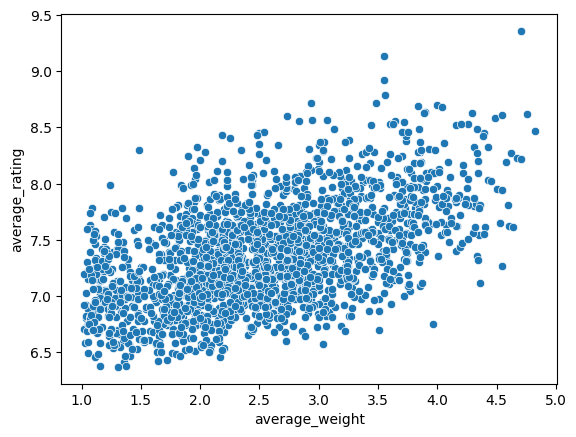

In [45]:
#plotting scatter plots for avg rating against avg weights- does more pervcieved complexity correalate with less enjoyment of a game 

sns.scatterplot(data=games,y='average_rating',x='average_weight' )

print(correlation('average_rating','average_weight'))

Plotting the average rating of a game to its average weight( the perceived complexity of the game by the user) resulted in a strong positive correlation of 0.54(2dp). 

 This could mean that users found more complex games more engaging , and therefore enjoyable. 

                average_rating  users_rated
average_rating        1.000000     0.100205
users_rated           0.100205     1.000000


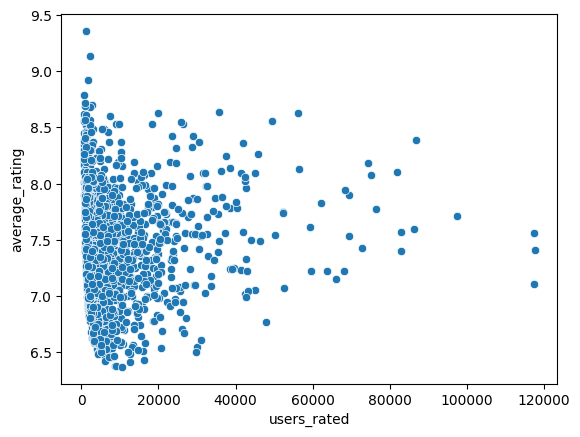

In [46]:
# do more ratings on a product lead it to have a higher overall rating ?
# correlation of 0.1 suggests no relationship betwwen the amount of ratings on a game and its enjoyment 
sns.scatterplot(data=games,y='average_rating',x='users_rated' )

print(correlation('average_rating','users_rated'))

Plotting the average rating against the number of users who rated a product had no correlation.

This could mean that the popularity of a product does not mean that it is well liked 

                average_rating  maxplaytime
average_rating        1.000000     0.121112
maxplaytime           0.121112     1.000000


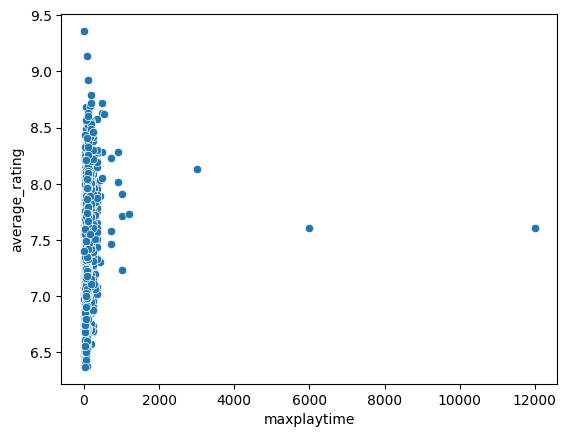

In [47]:
#does the playtime of a game impact its rating significantly 
#little correalation

sns.scatterplot(data=games,y='average_rating',x='maxplaytime' )

print(correlation('average_rating','maxplaytime'))





                maxplaytime  average_rating
maxplaytime        1.000000        0.353595
average_rating     0.353595        1.000000


<Axes: xlabel='maxplaytime', ylabel='average_rating'>

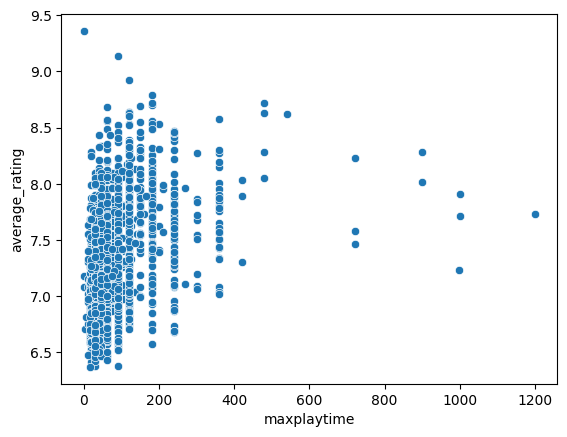

In [48]:

#trying again with getting rid of outliers 
# slightly hier, but still weak positive correalation 


games_outlier=games[games["maxplaytime"]<=2000]
temp= games_outlier[["maxplaytime","average_rating"]].copy()

print(temp.corr())

sns.scatterplot(data=games_outlier,y='average_rating',x='maxplaytime' )


Plotting the average rating of a game against its max playtime has a weak correlation, once outliers (above 1200 minutes) are removed. 

This could mean that that just becuase a game can be played for a long time, it may not be enagaging enough for players to find such an undertaking enjoyable 

                average_rating  honor_count
average_rating        1.000000     0.142258
honor_count           0.142258     1.000000


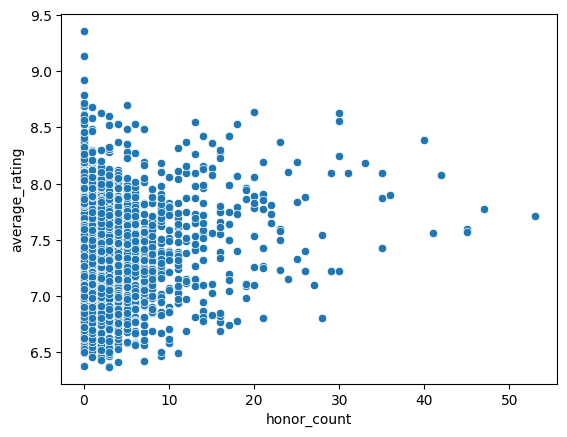

In [49]:
#Do a high amount of honors correlate to a high user rating
# Little correlation 
sns.scatterplot(data=games,y='average_rating',x='honor_count' )

print(correlation('average_rating','honor_count'))

Plotting the average rating for a game against the number of honors it received had no correlation. 

This could show a discrepency between how critics and players evaluate board games

                 average_rating  expansion_count
average_rating         1.000000         0.143078
expansion_count        0.143078         1.000000


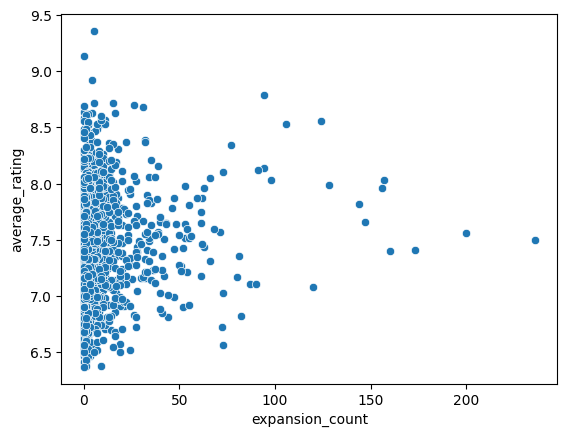

In [50]:
# do games with a larger amount of expansions have a higher user rating ?
# no real correlation 
sns.scatterplot(data=games,y='average_rating',x='expansion_count' )

print(correlation('average_rating','expansion_count'))


Plotting average rating of a game against the count of expansions released for it has no correlation. 

This could mean that commercial success for a board game ( i.e enough sales number to justify an expansion release), does not equate to  critical success

                average_rating   wishing
average_rating        1.000000  0.408385
wishing               0.408385  1.000000


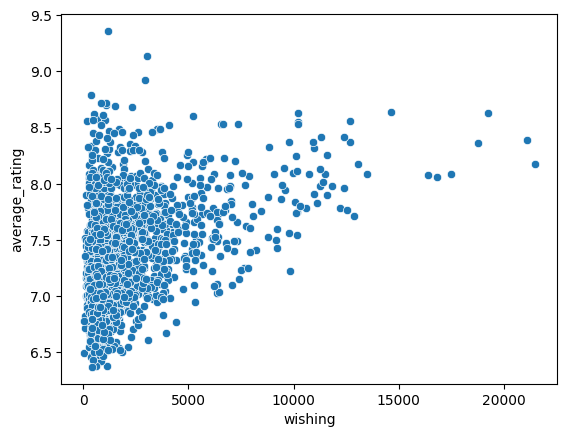

In [51]:
#Does a game with a high number of wishes correlate with a higher rating
# positive correalation
sns.scatterplot(data=games,y='average_rating',x='wishing' )

print(correlation('average_rating','wishing'))

Plotting a games average rating against the number of users who have the game wishlisted has a positive correlation. 

This may show that users intuition on what games they would enjoy playing based on prior expieriences are shown to be correct. 

                average_rating     owned
average_rating        1.000000  0.107832
owned                 0.107832  1.000000


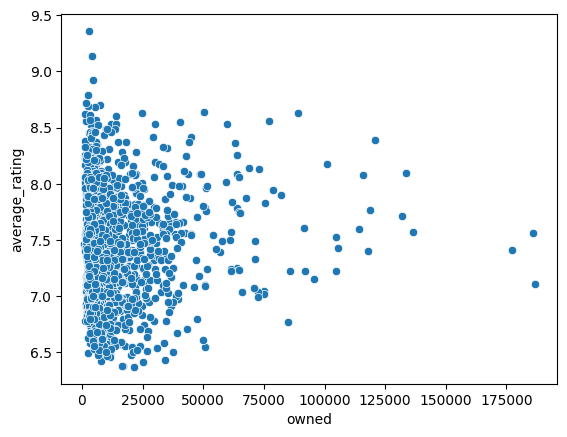

In [52]:
# does a game with a high number of owner tags correalate with higher ratings?
sns.scatterplot(data=games,y='average_rating',x='owned')

print(correlation('average_rating','owned'))

Plotting the average rating of a game against the number of registered owners yeilds little correlation.

 This again could show that the commercial success of a game does not impact its critical success

In [ ]:
#Above with the outliers removed 
# still not correlation
games_outlier=games[games["owned"]<=150000]
temp= games_outlier[["average_rating","owned"]].copy()

print(temp.corr())

sns.scatterplot(data=games_outlier,y='average_rating',x='maxplaytime' )

                average_rating   trading
average_rating        1.000000 -0.164433
trading              -0.164433  1.000000


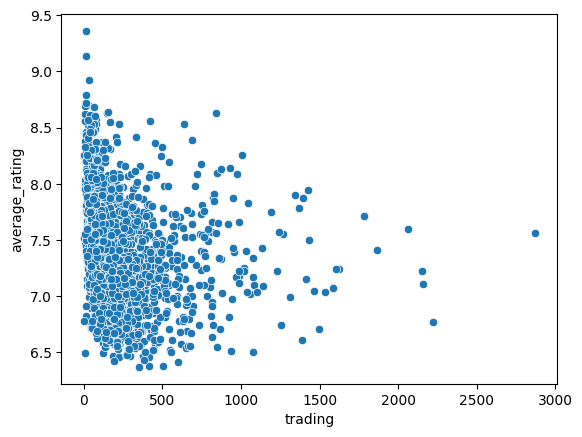

In [54]:
#Does a high number of users wanting to trade a game correlate with lower ratings?
sns.scatterplot(data=games,y='average_rating',x='trading')
# very weak negative correlation 
print(correlation('average_rating','trading'))

Plotting average rating against number of users trading the game had little correlation.

This could show that the main reason for users trading games may not be becuase they did not enjoy playing it 

These next graphs are to find correlation with the 'weights rating'. This rating is the users opinion on how complex a game is, going from 0 to 5 

                average_weight  mechanic_count
average_weight        1.000000        0.394268
mechanic_count        0.394268        1.000000


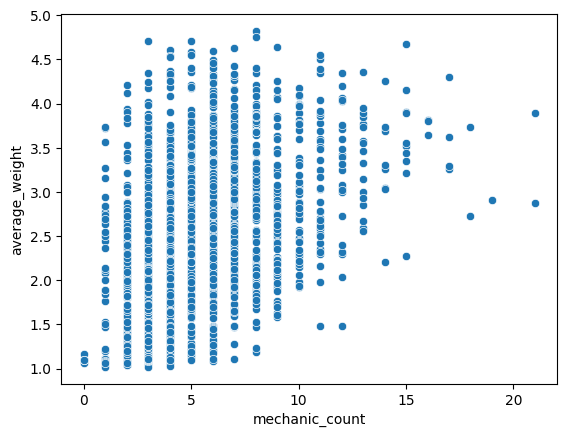

In [55]:
#For weights, does a high number of mechanics lead correlate with higher perceived complexity
# weak positive correalation

sns.scatterplot(data=games,y='average_weight',x='mechanic_count' )

print(correlation('average_weight','mechanic_count'))

Plotting the average weight for the game against the number of mechanics in the game yields a positive correlation. 

This could mean that games with more mechanics to learn are considered more complex by those who play them 

                average_weight       age
average_weight        1.000000  0.506675
age                   0.506675  1.000000


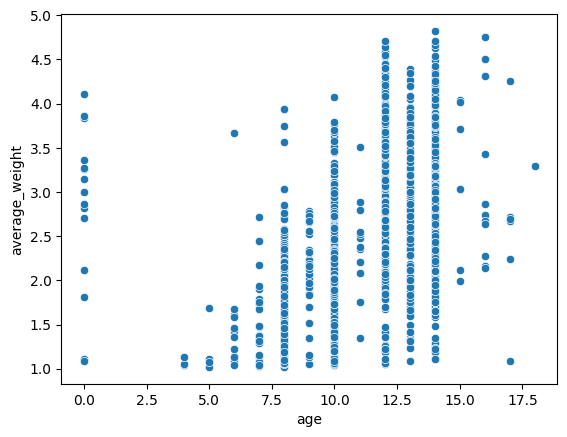

In [56]:
# does the age limit for  a game correllate with its complexity ?
#strong positive correlation

sns.scatterplot(data=games,y='average_weight',x='age' )

print(correlation('average_weight','age'))

Plotting  average weight against  the minimum recommended age for a  game results in  a strong positive correlation

This could show games inteded for older audiencees often have more complex mechanics 

                maxplaytime  average_weight
maxplaytime        1.000000        0.561331
average_weight     0.561331        1.000000


<Axes: xlabel='maxplaytime', ylabel='average_weight'>

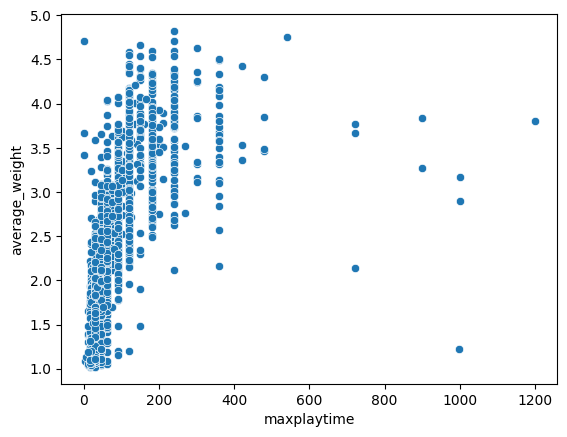

In [57]:
#Does a higher max playtime correlate with more complexity- with outliers removed ?
# strong positive correlation 
games_outlier=games[games["maxplaytime"]<=2000]
temp= games_outlier[["maxplaytime","average_weight"]].copy()

print(temp.corr())

sns.scatterplot(data=games_outlier,y='average_weight',x='maxplaytime' )

Plotting the average weight of a game against the maximum amount of time a game is said to take results in a strong positive correlation.

This could show that games with more complex mechanics take longer to complete